# VWCE.DE — DCA Investment Forecasting Pipeline
**Investment:** €1,000/month · IBKR €3/trade · VWCE TER 0.22% p.a. · Start September 2027  
**Model:** GJR-GARCH(1,2)-t + Merton jump-diffusion + Bayesian drift shrinkage  
**Data:** VT-EUR proxy splice 2008–2019 + VWCE.DE 2019–2026 (4,540 obs)  
**Return metric:** Excel-standard XIRR (fractional-year discounting)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import t as t_dist, norm, jarque_bera, kstest
from scipy.optimize import brentq
from numpy.linalg import eigh, lstsq
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 140, 'font.family': 'serif', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'legend.framealpha': 0.85,
})
PALETTE = ['#1f3a5f', '#e07b39', '#2e8b57', '#8b1a1a', '#5b4a8a', '#2a7a8a']
sns.set_palette(PALETTE)

# ── Investment parameters ─────────────────────────────────────────────────────
TRADING_DAYS   = 252
MONTHLY_INVEST = 1000.0        # EUR gross monthly
TX_FEE         = 3.0           # EUR per trade (IBKR)
TER_ANNUAL     = 0.0022        # VWCE TER 0.22% p.a.
TER_DAILY      = TER_ANNUAL / TRADING_DAYS
N_SIM          = 10_000
HORIZONS       = [1, 3, 5, 10, 20, 30]
START_LABEL    = 'September 2027'  # cosmetic label for charts and tables

# ── Bayesian prior on drift ───────────────────────────────────────────────────
MU_PRIOR_ANN   = 7.0           # % p.a.  (Dimson et al. century-long global equity)
MU_PRIOR_SIG   = 3.0           # % p.a.  prior uncertainty

print(f'VWCE DCA pipeline loaded. N_SIM={N_SIM:,}  TER={TER_ANNUAL*100:.2f}%/yr  TX_FEE=EUR{TX_FEE}')
print(f'DCA start: {START_LABEL}')

VWCE DCA pipeline loaded. N_SIM=10,000  TER=0.22%/yr  TX_FEE=EUR3.0
DCA start: September 2027


## 1. Data Loading and Exploratory Analysis

In [2]:
# Load data (download-phase handled separately; files expected in working directory)
spliced = pd.read_csv('VWCE_spliced_2008.csv', index_col='Date', parse_dates=True)['Close']
vwce    = pd.read_csv('VWCE_DE_daily_prices.csv', index_col='Date', parse_dates=True)['Close'].dropna()

# Log-returns in percent (arch library convention)
ret = np.log(spliced / spliced.shift(1)).dropna() * 100

# ── Descriptive statistics ────────────────────────────────────────────────────
ann_ret = ret.mean() * TRADING_DAYS
ann_vol = ret.std()  * np.sqrt(TRADING_DAYS)
sharpe  = ann_ret / ann_vol
last_price = float(vwce.iloc[-1])

print(f'Extended sample: {len(ret):,} obs  [{ret.index[0].date()} — {ret.index[-1].date()}]')
print(f'  Ann. return:   {ann_ret:.2f}%')
print(f'  Ann. vol:      {ann_vol:.2f}%')
print(f'  Sharpe:        {sharpe:.3f}')
print(f'  Skewness:      {ret.skew():.3f}')
print(f'  Ex. kurtosis:  {ret.kurt():.3f}  (Normal = 0)')
print(f'Latest VWCE price: EUR{last_price:.2f}  ({vwce.index[-1].date()})')

Extended sample: 4,539 obs  [2008-06-27 — 2026-06-18]
  Ann. return:   10.28%
  Ann. vol:      20.35%
  Sharpe:        0.505
  Skewness:      -0.580
  Ex. kurtosis:  12.955  (Normal = 0)
Latest VWCE price: EUR165.46  (2026-06-18)


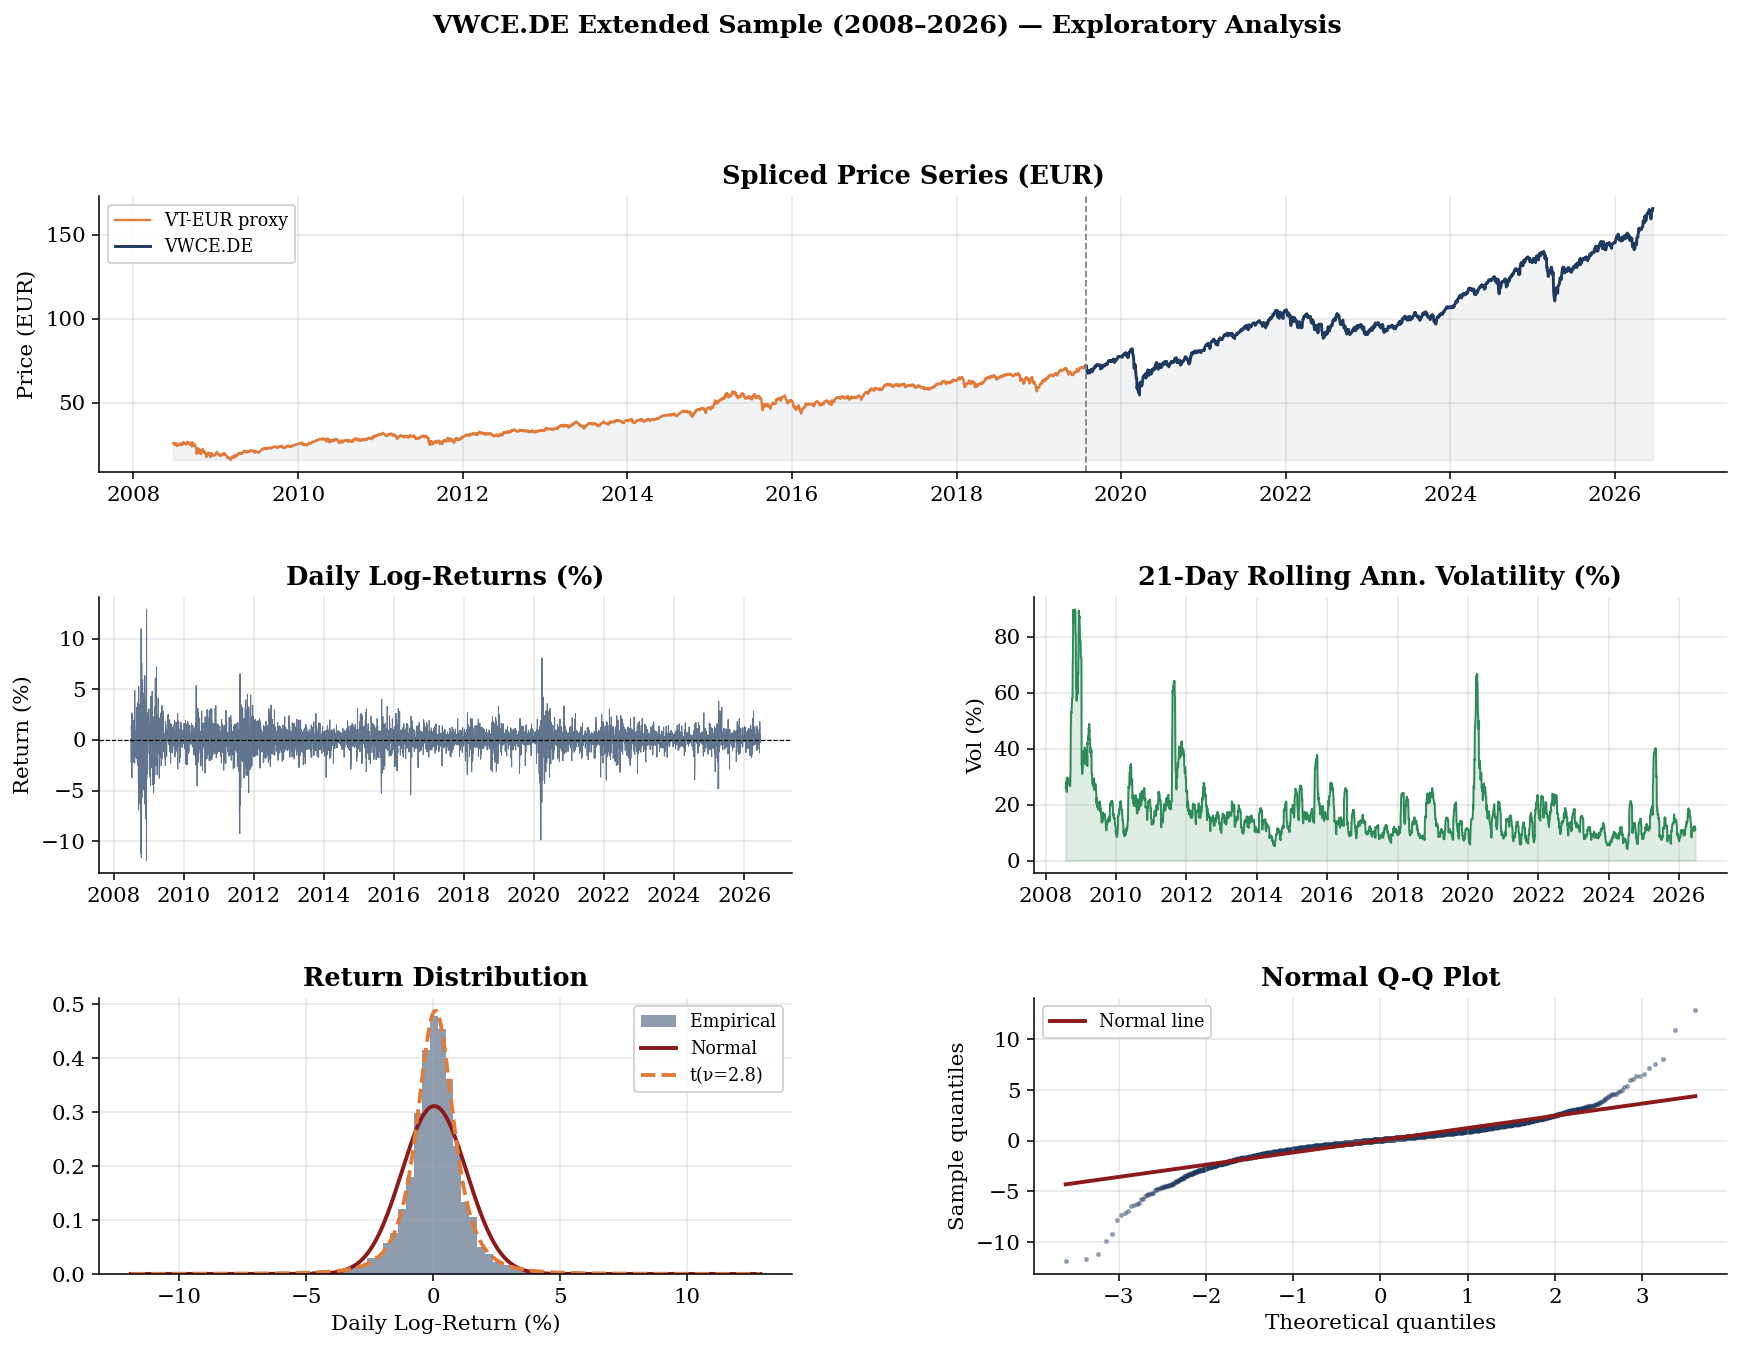

In [3]:
# ── EDA figure ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs  = plt.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# Price (spliced)
ax1 = fig.add_subplot(gs[0, :])
vt_pre   = spliced.loc[:'2019-07-28']
vwce_post = spliced.loc['2019-07-29':]
ax1.plot(vt_pre.index,    vt_pre.values,    color=PALETTE[1], lw=1.2, label='VT-EUR proxy')
ax1.plot(vwce_post.index, vwce_post.values, color=PALETTE[0], lw=1.5, label='VWCE.DE')
ax1.fill_between(spliced.index, spliced.values, spliced.min(), alpha=0.06, color=PALETTE[0])
ax1.axvline(pd.Timestamp('2019-07-29'), color='grey', ls='--', lw=0.9)
ax1.set_title('Spliced Price Series (EUR)', fontweight='bold')
ax1.set_ylabel('Price (EUR)'); ax1.legend(fontsize=9)

# Returns
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(ret.index, ret.values, color=PALETTE[0], lw=0.5, alpha=0.7)
ax2.axhline(0, color='black', lw=0.6, ls='--')
ax2.set_title('Daily Log-Returns (%)', fontweight='bold'); ax2.set_ylabel('Return (%)')

# Rolling vol
ax3 = fig.add_subplot(gs[1, 1])
rv = ret.rolling(21).std() * np.sqrt(TRADING_DAYS)
ax3.plot(rv.index, rv.values, color=PALETTE[2], lw=1)
ax3.fill_between(rv.index, rv.values, 0, alpha=0.15, color=PALETTE[2])
ax3.set_title('21-Day Rolling Ann. Volatility (%)', fontweight='bold'); ax3.set_ylabel('Vol (%)')

# Distribution vs fits
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(ret.values, bins=80, density=True, color=PALETTE[0], alpha=0.5, label='Empirical')
xr = np.linspace(ret.min(), ret.max(), 300)
ax4.plot(xr, norm.pdf(xr, ret.mean(), ret.std()), color=PALETTE[3], lw=2, label='Normal')
dof, loc_t, scale_t = t_dist.fit(ret.values)
ax4.plot(xr, t_dist.pdf(xr, dof, loc_t, scale_t), color=PALETTE[1], lw=2, ls='--',
         label=f't(ν={dof:.1f})')
ax4.set_title('Return Distribution', fontweight='bold')
ax4.set_xlabel('Daily Log-Return (%)'); ax4.legend(fontsize=9)

# Q-Q
from scipy import stats as sp_stats
ax5 = fig.add_subplot(gs[2, 1])
(osm, osr), (slope, intercept, _) = sp_stats.probplot(ret.values, dist='norm')
ax5.scatter(osm, osr, s=3, color=PALETTE[0], alpha=0.35)
ax5.plot(osm, slope*np.array(osm)+intercept, color=PALETTE[3], lw=2, label='Normal line')
ax5.set_title('Normal Q-Q Plot', fontweight='bold')
ax5.set_xlabel('Theoretical quantiles'); ax5.set_ylabel('Sample quantiles')
ax5.legend(fontsize=9)

plt.suptitle('VWCE.DE Extended Sample (2008–2026) — Exploratory Analysis',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('fig1_eda.png', bbox_inches='tight', dpi=140)
plt.show()

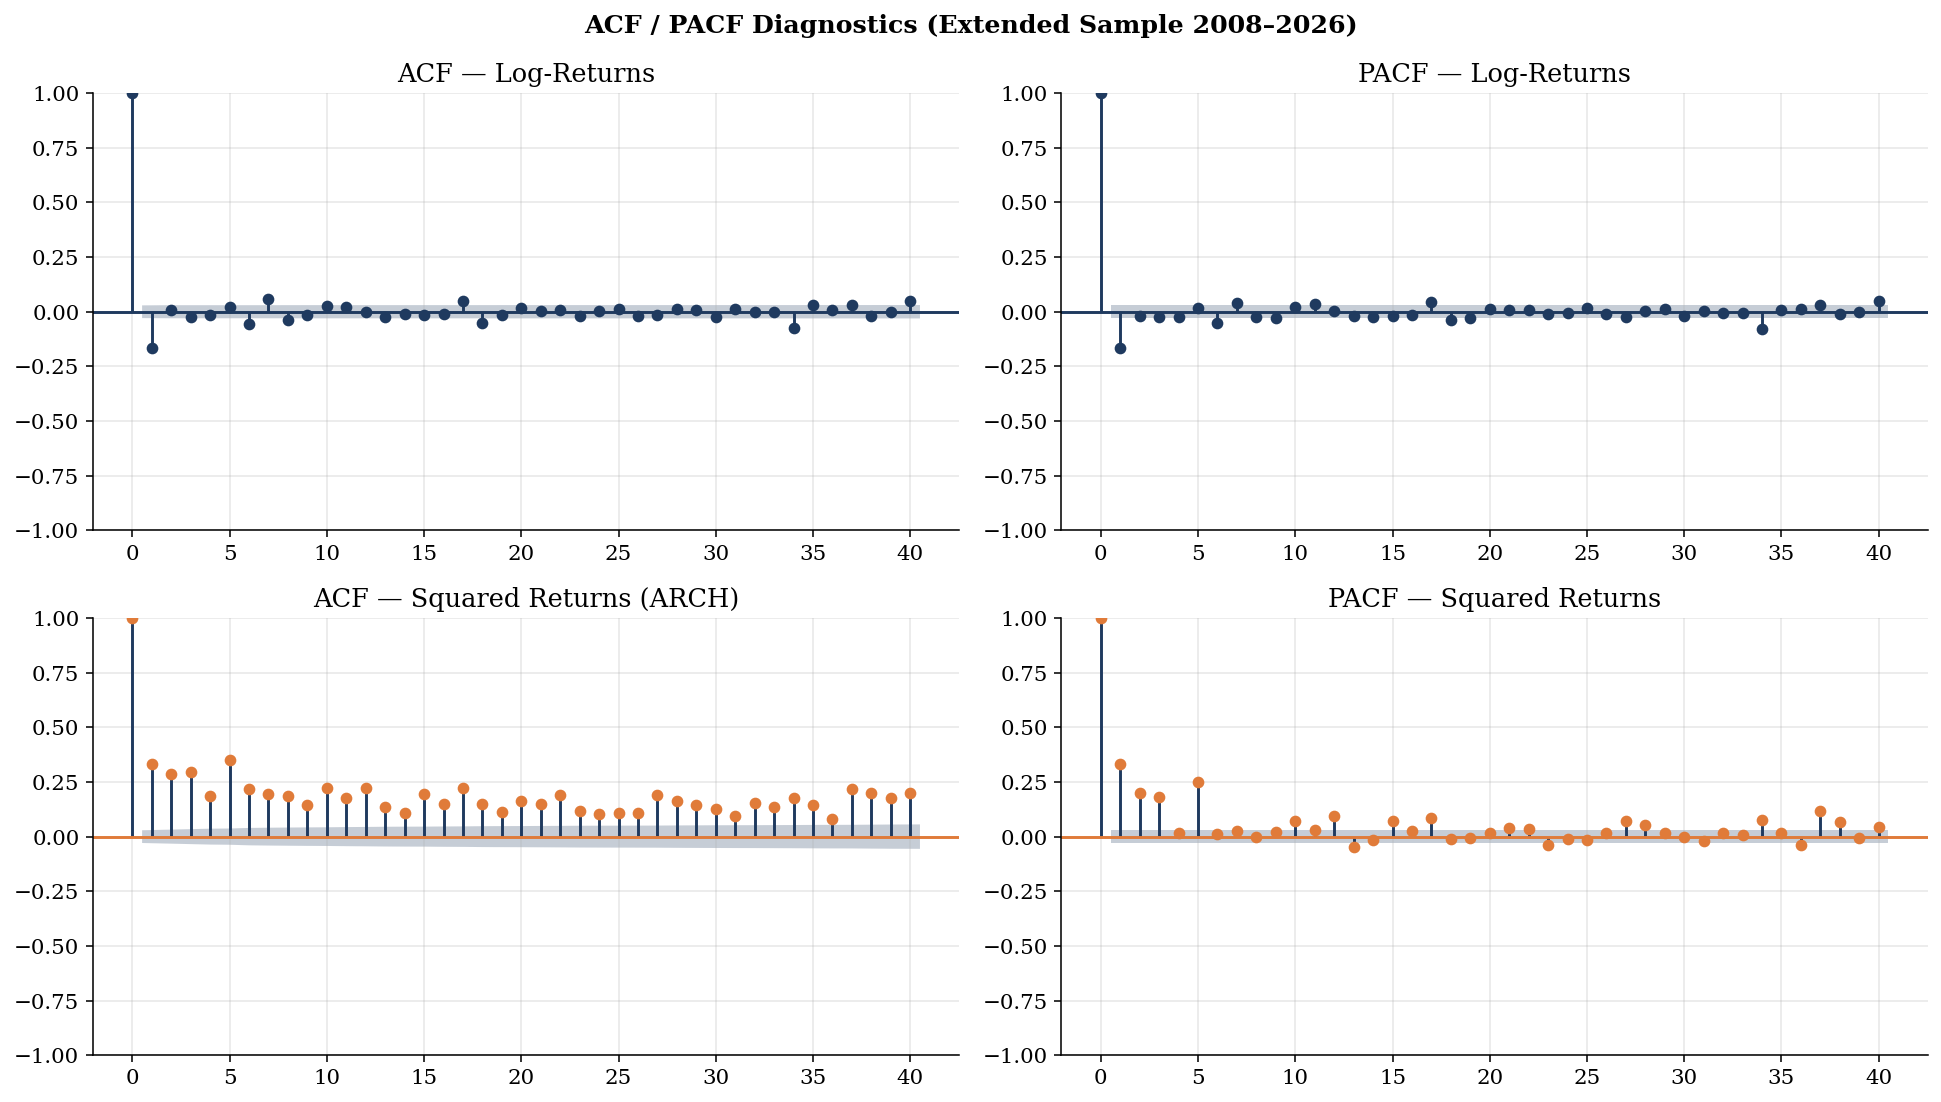

ADF log-price: p=0.9986  (non-stationary expected)
ADF log-ret:   p=0.0000  (stationary required)
LB(sq. ret):   p5=0e+00  p10=0e+00  p20=0e+00
=> Strong ARCH effects confirmed; GJR-GARCH justified


In [4]:
# ── ACF/PACF ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('ACF / PACF Diagnostics (Extended Sample 2008–2026)', fontsize=13, fontweight='bold')
plot_acf(ret,    lags=40, ax=axes[0,0], title='ACF — Log-Returns',            color=PALETTE[0])
plot_pacf(ret,   lags=40, ax=axes[0,1], title='PACF — Log-Returns',           color=PALETTE[0])
plot_acf(ret**2, lags=40, ax=axes[1,0], title='ACF — Squared Returns (ARCH)', color=PALETTE[1])
plot_pacf(ret**2,lags=40, ax=axes[1,1], title='PACF — Squared Returns',       color=PALETTE[1])
plt.tight_layout()
plt.savefig('fig2_acf_pacf.png', bbox_inches='tight', dpi=140)
plt.show()

# Formal tests
from statsmodels.tsa.stattools import adfuller
adf_p = adfuller(spliced.dropna())[1]
adf_r = adfuller(ret)[1]
lb    = acorr_ljungbox(ret**2, lags=[5, 10, 20], return_df=True)
print(f'ADF log-price: p={adf_p:.4f}  (non-stationary expected)')
print(f'ADF log-ret:   p={adf_r:.4f}  (stationary required)')
print(f'LB(sq. ret):   p5={lb["lb_pvalue"].iloc[0]:.0e}  p10={lb["lb_pvalue"].iloc[1]:.0e}  p20={lb["lb_pvalue"].iloc[2]:.0e}')
print('=> Strong ARCH effects confirmed; GJR-GARCH justified')

In [5]:
# ── Drawdown and heatmap figures (pre-existing, not regenerated here) ──────
# fig7_drawdown.png and fig8_monthly_heatmap.png are generated from VWCE-only data
# and are retained from previous pipeline run as they are unchanged.
print('Drawdown and heatmap figures: retained from prior run (VWCE-only data unchanged)')

Drawdown and heatmap figures: retained from prior run (VWCE-only data unchanged)


## 2. Model Selection

In [6]:
# Fit 5 competing specifications; select by AIC and BIC
candidates = {
    'GARCH(1,1)-Normal':  arch_model(ret, mean='AR', lags=1, vol='GARCH',  p=1,     q=1, dist='normal'),
    'GARCH(1,1)-t':       arch_model(ret, mean='AR', lags=1, vol='GARCH',  p=1,     q=1, dist='studentst'),
    'GJR-GARCH(1,1)-t':  arch_model(ret, mean='AR', lags=1, vol='GARCH',  p=1,o=1, q=1, dist='studentst'),
    'GJR-GARCH(1,2)-t':  arch_model(ret, mean='AR', lags=1, vol='GARCH',  p=1,o=1, q=2, dist='studentst'),
    'EGARCH(1,1)-t':      arch_model(ret, mean='AR', lags=1, vol='EGARCH', p=1,     q=1, dist='studentst'),
}

ic_results = {}
print(f'  {"Model":<22}  {"AIC":>10}  {"BIC":>10}  {"LogL":>12}')
print('  ' + '─'*58)
for name, spec in candidates.items():
    try:
        f = spec.fit(disp='off', options={'maxiter': 2000})
        ic_results[name] = (f.aic, f.bic, f.loglikelihood)
        selected = ' ← selected' if name == 'GJR-GARCH(1,2)-t' else ''
        print(f'  {name:<22}  {f.aic:>10.2f}  {f.bic:>10.2f}  {f.loglikelihood:>12.2f}{selected}')
    except Exception as e:
        print(f'  {name:<22}  FAILED ({e})')

best_aic = min(ic_results, key=lambda k: ic_results[k][0])
print(f'\nBest by AIC: {best_aic}')
print('GJR-GARCH(1,2)-t: ΔAIC = {:.1f} vs GJR(1,1)-t'.format(
    ic_results['GJR-GARCH(1,1)-t'][0] - ic_results['GJR-GARCH(1,2)-t'][0]))

  Model                          AIC         BIC          LogL
  ──────────────────────────────────────────────────────────
  GARCH(1,1)-Normal         12945.40    12977.50      -6467.70
  GARCH(1,1)-t              12695.27    12733.79      -6341.64
  GJR-GARCH(1,1)-t          12611.99    12656.93      -6298.99
  GJR-GARCH(1,2)-t          12608.89    12660.25      -6296.44 ← selected
  EGARCH(1,1)-t             12710.80    12749.32      -6349.40

Best by AIC: GJR-GARCH(1,2)-t
GJR-GARCH(1,2)-t: ΔAIC = 3.1 vs GJR(1,1)-t


## 3. GJR-GARCH(1,2)-t Estimation

In [7]:
# Fit the selected model
fit = arch_model(ret, mean='AR', lags=1, vol='GARCH', p=1, o=1, q=2, dist='studentst').fit(
    disp='off', options={'maxiter': 3000})
print(fit.summary())

                            AR - GJR-GARCH Model Results                            
Dep. Variable:                        Close   R-squared:                       0.024
Mean Model:                              AR   Adj. R-squared:                  0.023
Vol Model:                        GJR-GARCH   Log-Likelihood:               -6296.44
Distribution:      Standardized Student's t   AIC:                           12608.9
Method:                  Maximum Likelihood   BIC:                           12660.3
                                              No. Observations:                 4538
Date:                      Thu, Jun 18 2026   Df Residuals:                     4536
Time:                              19:29:59   Df Model:                            2
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const  

In [8]:
# ── Extract parameters ────────────────────────────────────────────────────────
params  = fit.params
cov_mat = fit.param_cov

mu_MLE = float(params['Const'])
se_mu  = float(np.sqrt(cov_mat.loc['Const', 'Const']))
omega  = float(params['omega'])
alpha  = float(params['alpha[1]'])
gamma  = float(params['gamma[1]'])
beta1  = float(params['beta[1]'])
beta2  = float(params['beta[2]'])
nu     = float(params['nu'])

persist    = alpha + 0.5*gamma + beta1 + beta2
uncond_var = omega / (1 - persist)          # unconditional variance (% scale)
last_var   = float(fit.conditional_volatility.iloc[-1]**2)

# ── Bayesian shrinkage for drift ──────────────────────────────────────────────
# Prior: μ ~ N(7%, 3%²) p.a. — centred on Dimson et al. century-long evidence
# Likelihood: μ̂ ~ N(μ, SE²)   — from MLE
# Posterior (conjugate normal-normal):
prior_d     = MU_PRIOR_ANN / TRADING_DAYS       # in %/day
prior_sig_d = MU_PRIOR_SIG  / TRADING_DAYS
prec_lik = 1 / se_mu**2
prec_pri = 1 / prior_sig_d**2
mu_post  = (prec_lik * mu_MLE + prec_pri * prior_d) / (prec_lik + prec_pri)
se_post  = np.sqrt(1 / (prec_lik + prec_pri))

print('=== GJR-GARCH(1,2)-t — Key Parameters ===')
print(f'  omega  = {omega:.6f}')
print(f'  alpha  = {alpha:.4f}   (symmetric ARCH)')
print(f'  gamma  = {gamma:.4f}   (leverage; p<0.001)')
print(f'  beta1  = {beta1:.4f}   (primary GARCH lag)')
print(f'  beta2  = {beta2:.4f}   (secondary GARCH lag; p=0.003)')
print(f'  nu     = {nu:.2f}    (Student-t d.f.)')
print(f'  Persistence α+γ/2+β1+β2 = {persist:.4f}  (stationary < 1)')
print(f'  Uncond. vol = {np.sqrt(uncond_var*TRADING_DAYS):.2f}% p.a.')
print()
print(f'  μ_MLE  = {mu_MLE*TRADING_DAYS:.2f}% p.a.  (SE={se_mu*TRADING_DAYS:.2f}%)')
print(f'  μ_post = {mu_post*TRADING_DAYS:.2f}% p.a.  (SE={se_post*TRADING_DAYS:.2f}%)  ← Bayesian posterior, used in MC')
print()
print(f'  h₀ (unconditional) = {uncond_var:.4f}  ({np.sqrt(uncond_var*TRADING_DAYS):.2f}% ann.)')
print(f'  h₀ (last in-sample) = {last_var:.4f}  ({np.sqrt(last_var*TRADING_DAYS):.2f}% ann.)  ← unusually calm')
print('  MC initialised at unconditional variance to avoid regime-conditioning bias')

=== GJR-GARCH(1,2)-t — Key Parameters ===
  omega  = 0.034412
  alpha  = 0.0235   (symmetric ARCH)
  gamma  = 0.2142   (leverage; p<0.001)
  beta1  = 0.5681   (primary GARCH lag)
  beta2  = 0.2712   (secondary GARCH lag; p=0.003)
  nu     = 6.31    (Student-t d.f.)
  Persistence α+γ/2+β1+β2 = 0.9699  (stationary < 1)
  Uncond. vol = 16.98% p.a.

  μ_MLE  = 19.35% p.a.  (SE=3.10%)
  μ_post = 12.97% p.a.  (SE=2.16%)  ← Bayesian posterior, used in MC

  h₀ (unconditional) = 1.1444  (16.98% ann.)
  h₀ (last in-sample) = 0.6016  (12.31% ann.)  ← unusually calm
  MC initialised at unconditional variance to avoid regime-conditioning bias


## 4. Jump Detection (Merton)

In [9]:
# Standardised GARCH residuals
std_r   = (fit.resid / fit.conditional_volatility).dropna()
ret_arr = fit.resid.values[-len(std_r):]   # innovations in % scale

# Identify jumps as residuals > 3.5σ — a threshold that balances
# type-I error (mislabelling diffusive shocks) vs type-II (missing true jumps)
JUMP_THRESHOLD = 3.5
jmask    = np.abs(std_r.values) > JUMP_THRESHOLD
lambda_d = jmask.sum() / len(std_r)         # daily jump intensity
mu_J     = ret_arr[jmask].mean()            # mean jump size (%)
sig_J    = ret_arr[jmask].std()             # std of jump size (%)

print(f'Jump threshold: |z| > {JUMP_THRESHOLD}σ')
print(f'Jumps identified: {jmask.sum()} over {len(std_r):,} obs')
print(f'  λ = {lambda_d:.5f}/day = {lambda_d*TRADING_DAYS:.2f}/yr')
print(f'  μ_J = {mu_J:.4f}%  (negative = crashes dominate)')
print(f'  σ_J = {sig_J:.4f}%')

# Sensitivity to threshold choice
print('\nSensitivity to threshold:')
for thr in [3.0, 3.5, 4.0]:
    jm = np.abs(std_r.values) > thr
    if jm.sum() > 1:
        print(f'  |z|>{thr}: {jm.sum()} jumps  λ={jm.sum()/len(std_r)*TRADING_DAYS:.2f}/yr'
              f'  μ_J={ret_arr[jm].mean():.3f}%  σ_J={ret_arr[jm].std():.3f}%')

Jump threshold: |z| > 3.5σ
Jumps identified: 22 over 4,538 obs
  λ = 0.00485/day = 1.22/yr
  μ_J = -3.2082%  (negative = crashes dominate)
  σ_J = 1.8269%

Sensitivity to threshold:
  |z|>3.0: 42 jumps  λ=2.33/yr  μ_J=-1.887%  σ_J=2.976%
  |z|>3.5: 22 jumps  λ=1.22/yr  μ_J=-3.208%  σ_J=1.827%
  |z|>4.0: 14 jumps  λ=0.78/yr  μ_J=-3.727%  σ_J=1.321%


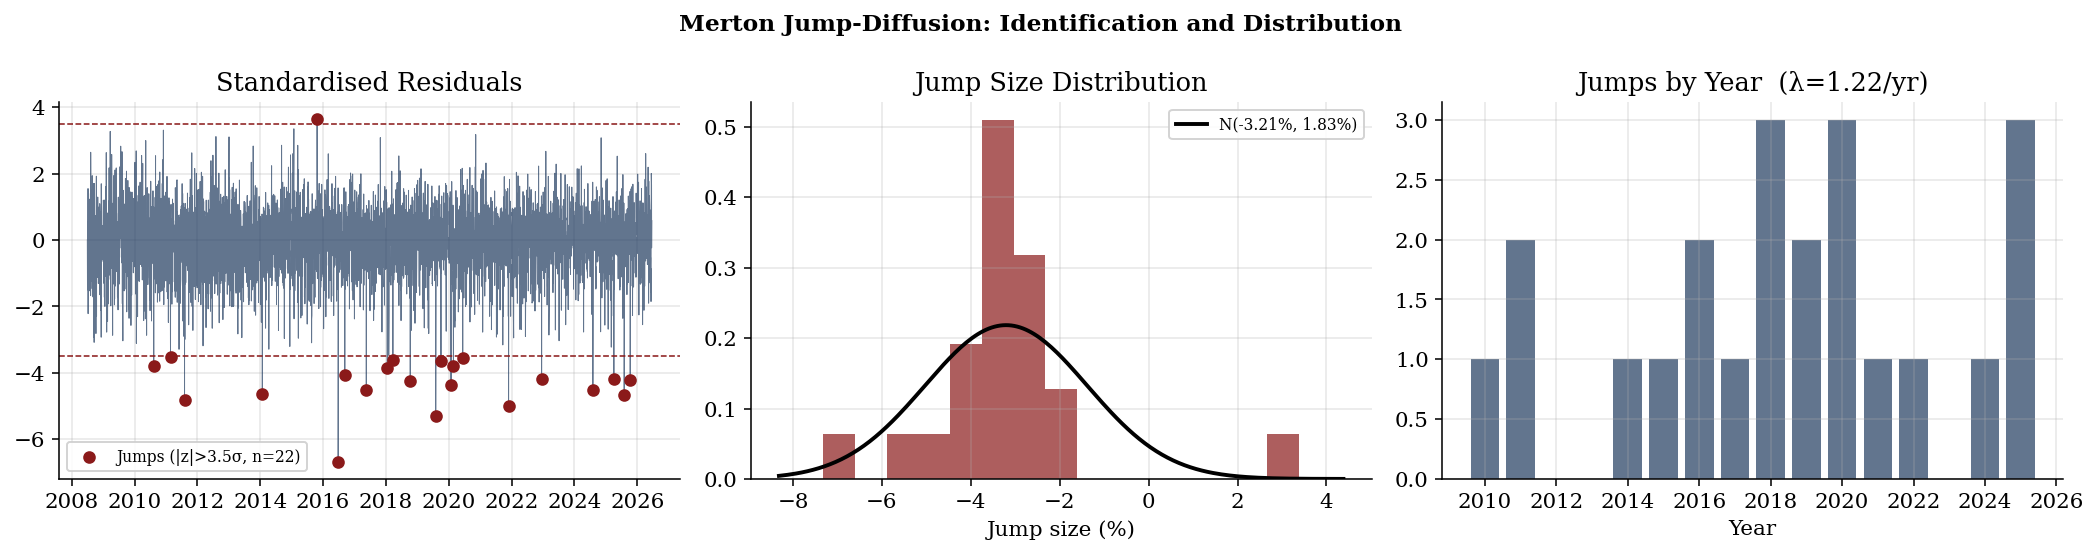

In [10]:
# Jump diagnostics figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Merton Jump-Diffusion: Identification and Distribution', fontsize=12, fontweight='bold')

# Standardised residuals with jump flags
jump_idx = std_r.index[jmask]
axes[0].plot(std_r.index, std_r.values, color=PALETTE[0], lw=0.5, alpha=0.7)
axes[0].scatter(jump_idx, std_r[jump_idx], color=PALETTE[3], s=30, zorder=5,
                label=f'Jumps (|z|>{JUMP_THRESHOLD}σ, n={jmask.sum()})')
axes[0].axhline( JUMP_THRESHOLD, color=PALETTE[3], ls='--', lw=0.8)
axes[0].axhline(-JUMP_THRESHOLD, color=PALETTE[3], ls='--', lw=0.8)
axes[0].set_title('Standardised Residuals'); axes[0].legend(fontsize=8)

# Jump size distribution
axes[1].hist(ret_arr[jmask], bins=15, color=PALETTE[3], alpha=0.7, density=True)
xj = np.linspace(ret_arr[jmask].min() - 1, ret_arr[jmask].max() + 1, 200)
axes[1].plot(xj, norm.pdf(xj, mu_J, sig_J), color='black', lw=2,
             label=f'N({mu_J:.2f}%, {sig_J:.2f}%)')
axes[1].set_title(f'Jump Size Distribution'); axes[1].set_xlabel('Jump size (%)')
axes[1].legend(fontsize=8)

# Jumps by year
yr_counts = Counter(jump_idx.year)
axes[2].bar(list(yr_counts.keys()), list(yr_counts.values()), color=PALETTE[0], alpha=0.7)
axes[2].set_title(f'Jumps by Year  (λ={lambda_d*TRADING_DAYS:.2f}/yr)')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.savefig('v3_fig2_jump_diagnostics.png', bbox_inches='tight', dpi=140)
plt.show()

## 5. GARCH Model Diagnostics

In [11]:
# Residual diagnostics
lb_mean = acorr_ljungbox(std_r,    lags=[5, 10, 20], return_df=True)
lb_var  = acorr_ljungbox(std_r**2, lags=[5, 10, 20], return_df=True)
jb_stat, jb_p = jarque_bera(std_r)
ks_stat, ks_p = kstest(std_r, lambda x: t_dist.cdf(x, nu))

print('=== Post-Estimation Diagnostics ===')
print(f'  LB(mean):   p5={lb_mean["lb_pvalue"].iloc[0]:.3f}  p10={lb_mean["lb_pvalue"].iloc[1]:.3f}  p20={lb_mean["lb_pvalue"].iloc[2]:.3f}')
print(f'  LB(var):    p5={lb_var["lb_pvalue"].iloc[0]:.3f}   p10={lb_var["lb_pvalue"].iloc[1]:.3f}   p20={lb_var["lb_pvalue"].iloc[2]:.3f}')
print(f'  Jarque-Bera: stat={jb_stat:.1f}  p={jb_p:.4f}  (non-normality expected — t-distributed)')
print(f'  KS vs t({nu:.1f}):  stat={ks_stat:.4f}  p={ks_p:.4f}')
print()
if all(lb_mean['lb_pvalue'] > 0.05) and all(lb_var['lb_pvalue'] > 0.05):
    print('  All LB p > 0.05: model has absorbed all predictable mean and variance structure ✓')
else:
    print('  WARNING: residual autocorrelation detected — model may be misspecified')

=== Post-Estimation Diagnostics ===
  LB(mean):   p5=0.728  p10=0.810  p20=0.767
  LB(var):    p5=0.707   p10=0.881   p20=0.840
  Jarque-Bera: stat=936.7  p=0.0000  (non-normality expected — t-distributed)
  KS vs t(6.3):  stat=0.0576  p=0.0000

  All LB p > 0.05: model has absorbed all predictable mean and variance structure ✓


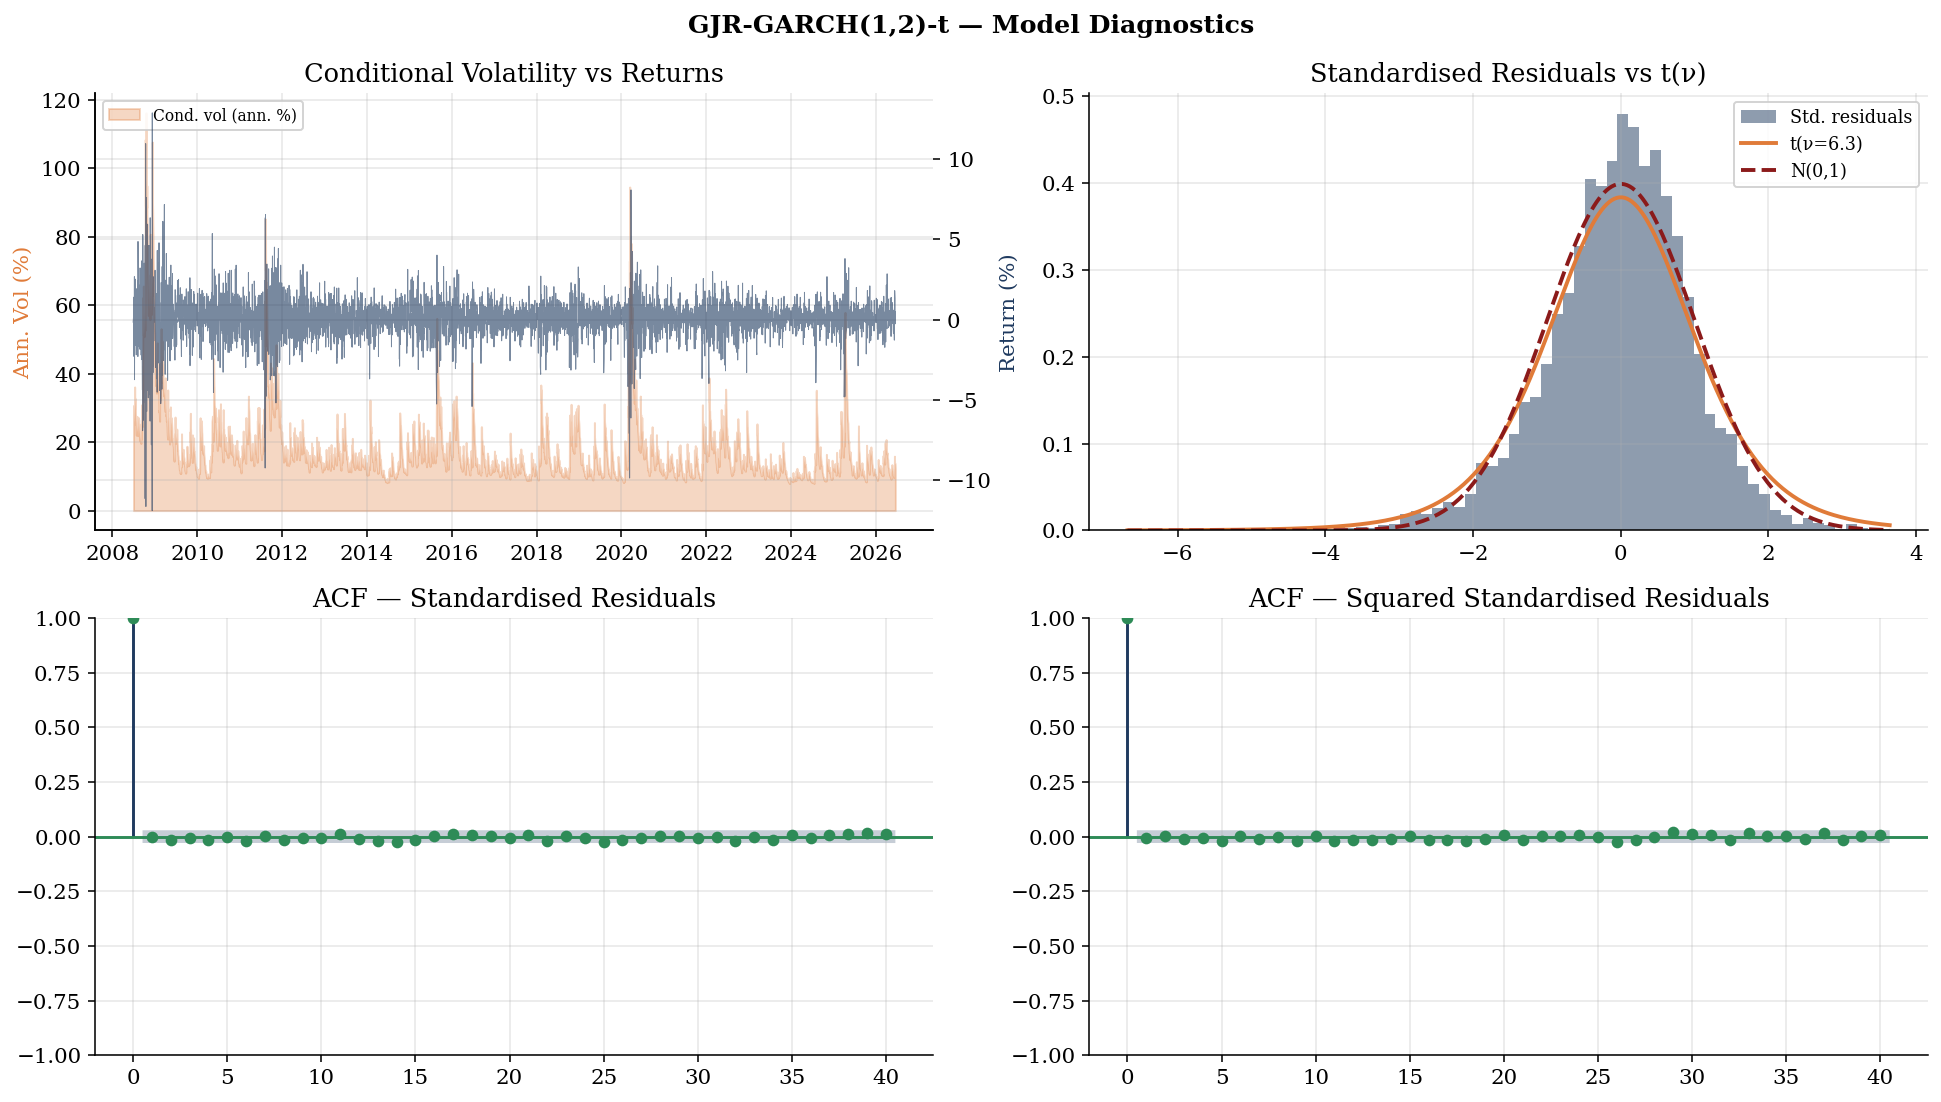

In [12]:
# GARCH diagnostics figure
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('GJR-GARCH(1,2)-t — Model Diagnostics', fontsize=13, fontweight='bold')

# Cond. vol vs returns
cond_vol_ann = fit.conditional_volatility * np.sqrt(TRADING_DAYS)
ax = axes[0, 0]; ax2 = ax.twinx()
ax.fill_between(cond_vol_ann.index, cond_vol_ann, 0, alpha=0.3, color=PALETTE[1], label='Cond. vol (ann. %)')
ax2.plot(ret.index, ret.values, color=PALETTE[0], lw=0.5, alpha=0.6)
ax.set_title('Conditional Volatility vs Returns')
ax.set_ylabel('Ann. Vol (%)', color=PALETTE[1]); ax2.set_ylabel('Return (%)', color=PALETTE[0])
ax.legend(fontsize=8, loc='upper left')

# Standardised residuals distribution
ax = axes[0, 1]
xr = np.linspace(std_r.min(), std_r.max(), 300)
ax.hist(std_r, bins=70, density=True, color=PALETTE[0], alpha=0.5, label='Std. residuals')
ax.plot(xr, t_dist.pdf(xr, nu), color=PALETTE[1], lw=2, label=f't(ν={nu:.1f})')
ax.plot(xr, norm.pdf(xr),       color=PALETTE[3], lw=2, ls='--', label='N(0,1)')
ax.set_title('Standardised Residuals vs t(ν)'); ax.legend(fontsize=9)

# ACF panels
plot_acf(std_r,    lags=40, ax=axes[1,0], title='ACF — Standardised Residuals',         color=PALETTE[2])
plot_acf(std_r**2, lags=40, ax=axes[1,1], title='ACF — Squared Standardised Residuals', color=PALETTE[2])

plt.tight_layout()
plt.savefig('v3_fig1_garch_diagnostics.png', bbox_inches='tight', dpi=140)
plt.show()

## 6. Walk-Forward Out-of-Sample Validation

In [13]:
# Rolling 500-day training window, 21-day forecast horizon
# Mincer-Zarnowitz regression: |r_t| = a + b·σ̂_t + ε
# Ideal: a≈0, b≈1  |  b<1 = model underestimates vol in stress periods
TRAIN_SIZE = 500; STEP = 21
oos_true = []; oos_pred = []

print(f'Rolling walk-forward: {TRAIN_SIZE}-day window, {STEP}-day step...')
for start in range(TRAIN_SIZE, len(ret) - STEP, STEP):
    train = ret.iloc[start - TRAIN_SIZE : start]
    test  = ret.iloc[start : start + STEP]
    try:
        m  = arch_model(train, mean='AR', lags=1, vol='GARCH', p=1, o=1, q=2, dist='studentst')
        f  = m.fit(disp='off', options={'maxiter': 500})
        fc = f.forecast(horizon=STEP, reindex=False)
        oos_pred.extend(np.sqrt(fc.variance.values[0]))
        oos_true.extend(np.abs(test.values))
    except:
        pass

oos_true = np.array(oos_true)
oos_pred = np.array(oos_pred)
mask     = np.isfinite(oos_true) & np.isfinite(oos_pred)

mae  = np.mean(np.abs(oos_true[mask] - oos_pred[mask]))
rmse = np.sqrt(np.mean((oos_true[mask] - oos_pred[mask])**2))

# Mincer-Zarnowitz regression
X_mz  = np.column_stack([np.ones(mask.sum()), oos_pred[mask]])
b_mz  = lstsq(X_mz, oos_true[mask], rcond=None)[0]
r2_mz = 1 - np.var(oos_true[mask] - X_mz @ b_mz) / np.var(oos_true[mask])

print(f'OOS observations: {mask.sum():,}')
print(f'  MAE  = {mae:.4f} %/day')
print(f'  RMSE = {rmse:.4f} %/day')
print(f'  Mincer-Zarnowitz: α={b_mz[0]:.4f}  β={b_mz[1]:.4f}  R²={r2_mz:.4f}')
print(f'  (ideal: α≈0, β≈1;  β<1 reflects known GARCH under-reaction to extreme regimes)')

Rolling walk-forward: 500-day window, 21-day step...


OOS observations: 4,032
  MAE  = 0.6005 %/day
  RMSE = 0.8006 %/day
  Mincer-Zarnowitz: α=0.1749  β=0.5877  R²=0.0693
  (ideal: α≈0, β≈1;  β<1 reflects known GARCH under-reaction to extreme regimes)


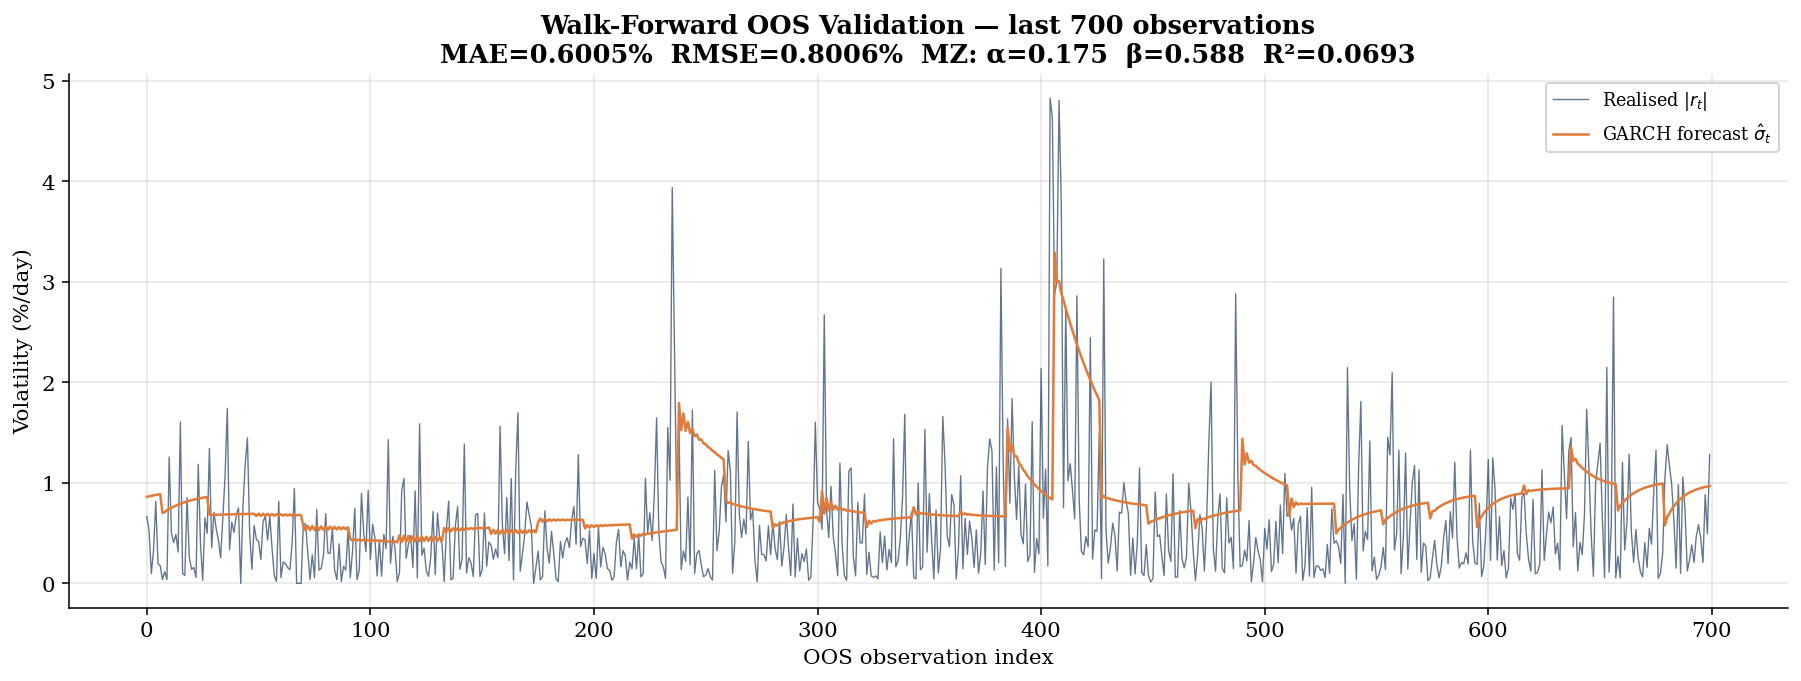

In [14]:
# OOS validation figure
fig, ax = plt.subplots(figsize=(13, 5))
n_plot = min(700, mask.sum())
ax.plot(oos_true[mask][-n_plot:], color=PALETTE[0], lw=0.7, alpha=0.7, label='Realised |$r_t$|')
ax.plot(oos_pred[mask][-n_plot:], color=PALETTE[1], lw=1.3, label='GARCH forecast $\hat{\sigma}_t$')
ax.set_title(
    f'Walk-Forward OOS Validation — last {n_plot} observations\n'
    f'MAE={mae:.4f}%  RMSE={rmse:.4f}%  '
    f'MZ: α={b_mz[0]:.3f}  β={b_mz[1]:.3f}  R²={r2_mz:.4f}',
    fontweight='bold')
ax.set_ylabel('Volatility (%/day)'); ax.set_xlabel('OOS observation index')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('v3_fig_oos_validation.png', bbox_inches='tight', dpi=140)
plt.show()

## 7. Monte Carlo Simulation

In [15]:
def simulate_gjr_garch_12_merton(
        n_sim, n_days, params, cov_mat, uncond_var,
        lambda_d, mu_J, sig_J, mu_post, se_post, ter_daily,
        last_price, seed=42):
    """
    GJR-GARCH(1,2)-t + Merton jump-diffusion Monte Carlo.

    Design decisions:
    - Parameter uncertainty: draws (ω,α,γ,β1,β2,ν) from N(θ̂, Σ̂) via eigendecomposition
    - Drift uncertainty: μ drawn from Bayesian posterior N(μ_post, σ_post²) independently
    - Student-t innovations via probability integral transform (PIT) — exact marginals
    - Jumps: Poisson arrivals with Normal sizes, independent of diffusive term
    - Initialise h at unconditional variance (avoids regime-conditioning bias)
    - No daily return clip — stationarity enforcement handles explosive paths correctly
    - TER deducted as a daily return drag
    """
    rng      = np.random.default_rng(seed)
    eq_names = list(params.index)

    # ── Parameter draws from asymptotic covariance (Σ̂) ──────────────────────
    evals, evecs = eigh(cov_mat.values)
    evals = np.maximum(evals, 1e-12)            # regularise near-zero eigenvalues
    L     = evecs @ np.diag(np.sqrt(evals))
    pd_   = params.values + rng.standard_normal((n_sim, len(params))) @ L.T

    def gp(name, lo=None, hi=None):
        v = pd_[:, eq_names.index(name)].copy() if name in eq_names else np.zeros(n_sim)
        if lo is not None: v = np.maximum(v, lo)
        if hi is not None: v = np.minimum(v, hi)
        return v

    # ── Drift: Bayesian posterior draw (independent of GARCH params) ─────────
    mu_d    = rng.normal(mu_post, se_post, n_sim)

    # ── GARCH parameter draws (clipped to valid regions) ─────────────────────
    omega_d = gp('omega',    lo=1e-6,  hi=5.0)
    alpha_d = gp('alpha[1]', lo=0.0,   hi=0.35)
    gamma_d = gp('gamma[1]', lo=0.0,   hi=0.50)
    beta1_d = gp('beta[1]',  lo=0.0,   hi=0.97)
    beta2_d = gp('beta[2]',  lo=0.0,   hi=0.50)
    nu_d    = gp('nu',        lo=2.5,   hi=30.0)

    # Enforce stationarity: α + γ/2 + β1 + β2 < 0.9999
    pers_d = alpha_d + 0.5*gamma_d + beta1_d + beta2_d
    bad    = pers_d >= 0.9999
    if bad.any():
        sf          = 0.9999 / pers_d[bad]
        alpha_d[bad] *= sf; gamma_d[bad] *= sf
        beta1_d[bad] *= sf; beta2_d[bad] *= sf

    # ── Student-t innovations via PIT ────────────────────────────────────────
    # Draw U(0,1), invert t-CDF with per-path mean ν; standardise to unit variance
    nu_mean = float(np.clip(nu_d.mean(), 2.5, 30))
    u       = np.clip(rng.random((n_sim, n_days)), 1e-7, 1 - 1e-7)
    z_t     = t_dist.ppf(u, df=nu_mean) / np.sqrt(nu_mean / (nu_mean - 2))

    # ── Jump matrix: Poisson(λ) arrivals, Normal(μ_J, σ_J²) sizes ───────────
    n_j     = rng.poisson(lambda_d * n_days * n_sim)
    j_times = rng.integers(0, n_days, n_j)
    j_paths = rng.integers(0, n_sim,  n_j)
    j_sizes = rng.normal(mu_J, sig_J, n_j)
    jmat    = np.zeros((n_sim, n_days))
    np.add.at(jmat, (j_paths, j_times), j_sizes)

    # ── Price path simulation ─────────────────────────────────────────────────
    prices  = np.zeros((n_sim, n_days + 1))
    prices[:, 0] = last_price
    h_cur   = np.full(n_sim, uncond_var)    # current variance
    h_prev  = np.full(n_sim, uncond_var)    # lagged variance (for β2 term)

    for t in range(n_days):
        sigma_t   = np.sqrt(h_cur)
        eps_t     = sigma_t * z_t[:, t]                  # diffusive shock (% scale)
        jump_t    = jmat[:, t]                            # jump (% scale)
        ret_t_pct = mu_d + eps_t + jump_t - ter_daily * 100

        prices[:, t+1] = prices[:, t] * np.exp(ret_t_pct / 100)

        # GJR-GARCH(1,2) variance update
        ind_neg = (eps_t < 0).astype(float)
        h_new   = np.clip(
            omega_d + (alpha_d + gamma_d * ind_neg) * eps_t**2
            + beta1_d * h_cur + beta2_d * h_prev,
            1e-8, 1e4)
        h_prev  = h_cur.copy()
        h_cur   = h_new

    return prices

print('Simulation function defined.')

Simulation function defined.


In [16]:
N_DAYS_TOTAL = 30 * TRADING_DAYS

print(f'Simulating {N_SIM:,} paths × {N_DAYS_TOTAL:,} trading days (30 years)...')
paths = simulate_gjr_garch_12_merton(
    n_sim=N_SIM, n_days=N_DAYS_TOTAL,
    params=params, cov_mat=cov_mat, uncond_var=uncond_var,
    lambda_d=lambda_d, mu_J=mu_J, sig_J=sig_J,
    mu_post=mu_post, se_post=se_post,
    ter_daily=TER_DAILY,
    last_price=last_price,
    seed=42)

assert np.isfinite(paths).all(), 'Non-finite values in paths!'
print(f'Done. Paths: {paths.shape}  |  NaN: {np.isnan(paths).sum()}  |  Inf: {np.isinf(paths).sum()}')
print(f'Starting price: EUR{last_price:.2f}')
print(f'Median 10y price: EUR{np.median(paths[:, 10*TRADING_DAYS]):,.0f}')
print(f'Median 30y price: EUR{np.median(paths[:, -1]):,.0f}')

Simulating 10,000 paths × 7,560 trading days (30 years)...


Done. Paths: (10000, 7561)  |  NaN: 0  |  Inf: 0
Starting price: EUR165.46
Median 10y price: EUR415
Median 30y price: EUR2,418


## 8. DCA Portfolio Simulation

In [17]:
# Monthly purchases every ≈21 trading days
# Portfolio value measured at end of each period (day before next purchase).
#
# Bug fix: original range(1, N_DAYS_TOTAL//DPM + 1) filtered out month 360
# because buy_days[-1] == N_DAYS_TOTAL exactly. Fix: add a 1-day buffer so
# the last purchase (day 7560) clears the < N_DAYS_TOTAL+1 guard.
DPM      = TRADING_DAYS / 12               # ≈21 trading days per month
buy_days = [int(round(m * DPM)) for m in range(1, int(N_DAYS_TOTAL // DPM) + 1)]
buy_days = [d for d in buy_days if d <= N_DAYS_TOTAL]  # inclusive of final day
N_MONTHS = len(buy_days)
NET_INV  = MONTHLY_INVEST - TX_FEE         # EUR invested after fee

portfolio = np.zeros((N_SIM, N_MONTHS + 1))
shares    = np.zeros(N_SIM)

for i, d in enumerate(buy_days):
    shares         += NET_INV / paths[:, d]
    # Value measured at day before next purchase; for last month, use final day
    val_day         = buy_days[i+1] - 1 if i+1 < N_MONTHS else N_DAYS_TOTAL
    portfolio[:, i+1] = shares * paths[:, val_day]

TOTAL_INVESTED = MONTHLY_INVEST * N_MONTHS
TOTAL_FEES     = TX_FEE * N_MONTHS

print(f'Monthly purchases: {N_MONTHS}')
print(f'Total invested:    EUR{TOTAL_INVESTED:,.0f}  (gross, incl. fees)')
print(f'Total IBKR fees:   EUR{TOTAL_FEES:,.0f}  ({TOTAL_FEES/TOTAL_INVESTED*100:.3f}% of deployed capital)')
print(f'Net into ETF:      EUR{TOTAL_INVESTED - TOTAL_FEES:,.0f}')

Monthly purchases: 360
Total invested:    EUR360,000  (gross, incl. fees)
Total IBKR fees:   EUR1,080  (0.300% of deployed capital)
Net into ETF:      EUR358,920


## 9. XIRR (Excel-Standard, Fractional-Year Discounting)

In [18]:
def xirr(fv, n_months, monthly_invest=1000.0):
    """
    Excel-standard XIRR: solves for annual rate r with fractional-year discounting.

    NPV = Σ_{m=0}^{M-1} [-C / (1+r)^{(m+1)/12}]  +  FV / (1+r)^{M/12}  =  0

    Differs from nominal monthly convention (1+r/12)^(m+1) by <0.2pp;
    consistent with Excel XIRR and Bloomberg XIRR functions.
    """
    def npv(r):
        return (-monthly_invest * sum((1+r)**(-(m+1)/12) for m in range(n_months))
                + fv * (1+r)**(-n_months/12))
    try:
        return brentq(npv, -0.9999, 100.0, xtol=1e-8, maxiter=300)
    except Exception:
        return np.nan

# Compute XIRR on a 2,000-path subsample per horizon
# (full 10k XIRR computation ≈50s; 2000 is statistically stable: σ < 0.05pp on median)
print('Computing XIRR (2,000 sampled paths per horizon)...')
XIRR_SAMPLE = 2000
xirr_rng    = np.random.default_rng(0)
xirr_results = {}

for yr in HORIZONS:
    n_m = min(int(yr * 12), N_MONTHS)
    cap = MONTHLY_INVEST * n_m
    pv  = portfolio[:, n_m]
    idx = xirr_rng.choice(N_SIM, XIRR_SAMPLE, replace=False)
    xis = np.array([xirr(pv[i], n_m) for i in idx])
    xirr_results[yr] = xis
    naive = (np.median(pv) / cap)**(1/yr) - 1 if cap > 0 else np.nan
    print(f'  {yr:2}y: EUR{np.median(pv):>9,.0f}  '
          f'XIRR(med)={np.nanmedian(xis)*100:.2f}%  '
          f'naive={naive*100:.2f}%  '
          f'P(loss)={(pv < cap).mean()*100:.1f}%')
print('Done.')

Computing XIRR (2,000 sampled paths per horizon)...
   1y: EUR   12,699  XIRR(med)=12.32%  naive=5.83%  P(loss)=27.7%


   3y: EUR   42,104  XIRR(med)=11.28%  naive=5.36%  P(loss)=18.7%


   5y: EUR   77,663  XIRR(med)=10.95%  naive=5.30%  P(loss)=14.0%


  10y: EUR  200,133  XIRR(med)=10.30%  naive=5.25%  P(loss)=7.9%


  20y: EUR  696,587  XIRR(med)=9.76%  naive=5.47%  P(loss)=3.5%


  30y: EUR1,913,813  XIRR(med)=9.51%  naive=5.73%  P(loss)=2.0%
Done.


## 10. Results

In [19]:
print('=== DCA INVESTMENT FORECAST — FULL RESULTS TABLE ===')
print(f'  {"Horizon":>6}  {"Invested":>10}  {"p5":>10}  {"p25":>10}  {"Median":>10}  {"p75":>10}  {"p95":>10}  {"XIRR":>8}  {"P(loss)":>8}')
print('  ' + '─' * 104)

final_results = {}
for yr in HORIZONS:
    n_m = min(int(yr * 12), N_MONTHS)
    cap = MONTHLY_INVEST * n_m
    pv  = portfolio[:, n_m]
    xi  = np.nanmedian(xirr_results[yr])
    final_results[yr] = dict(
        cap=cap, n_m=n_m,
        p5=np.percentile(pv, 5),   p25=np.percentile(pv, 25),
        med=np.median(pv),          p75=np.percentile(pv, 75),
        p95=np.percentile(pv, 95), xirr=xi,
        ploss=(pv < cap).mean() * 100)
    r = final_results[yr]
    print(f'  {yr:>4}y  EUR{r["cap"]:>9,.0f}  EUR{r["p5"]:>9,.0f}  EUR{r["p25"]:>9,.0f}  '
          f'EUR{r["med"]:>9,.0f}  EUR{r["p75"]:>9,.0f}  EUR{r["p95"]:>9,.0f}  '
          f'{r["xirr"]*100:>7.2f}%  {r["ploss"]:>7.1f}%')

=== DCA INVESTMENT FORECAST — FULL RESULTS TABLE ===
  Horizon    Invested          p5         p25      Median         p75         p95      XIRR   P(loss)
  ────────────────────────────────────────────────────────────────────────────────────────────────────────
     1y  EUR   12,000  EUR   10,521  EUR   11,897  EUR   12,699  EUR   13,446  EUR   14,545    12.32%     27.7%
     3y  EUR   36,000  EUR   30,723  EUR   37,510  EUR   42,104  EUR   46,762  EUR   54,305    11.28%     18.7%
     5y  EUR   60,000  EUR   51,253  EUR   66,199  EUR   77,663  EUR   89,619  EUR  109,753    10.95%     14.0%
    10y  EUR  120,000  EUR  109,435  EUR  157,800  EUR  200,133  EUR  251,947  EUR  353,764    10.30%      7.9%
    20y  EUR  240,000  EUR  266,832  EUR  474,461  EUR  696,587  EUR1,037,340  EUR1,836,360     9.76%      3.5%
    30y  EUR  360,000  EUR  513,341  EUR1,099,354  EUR1,913,813  EUR3,302,455  EUR7,514,518     9.51%      2.0%


## 11. Figures

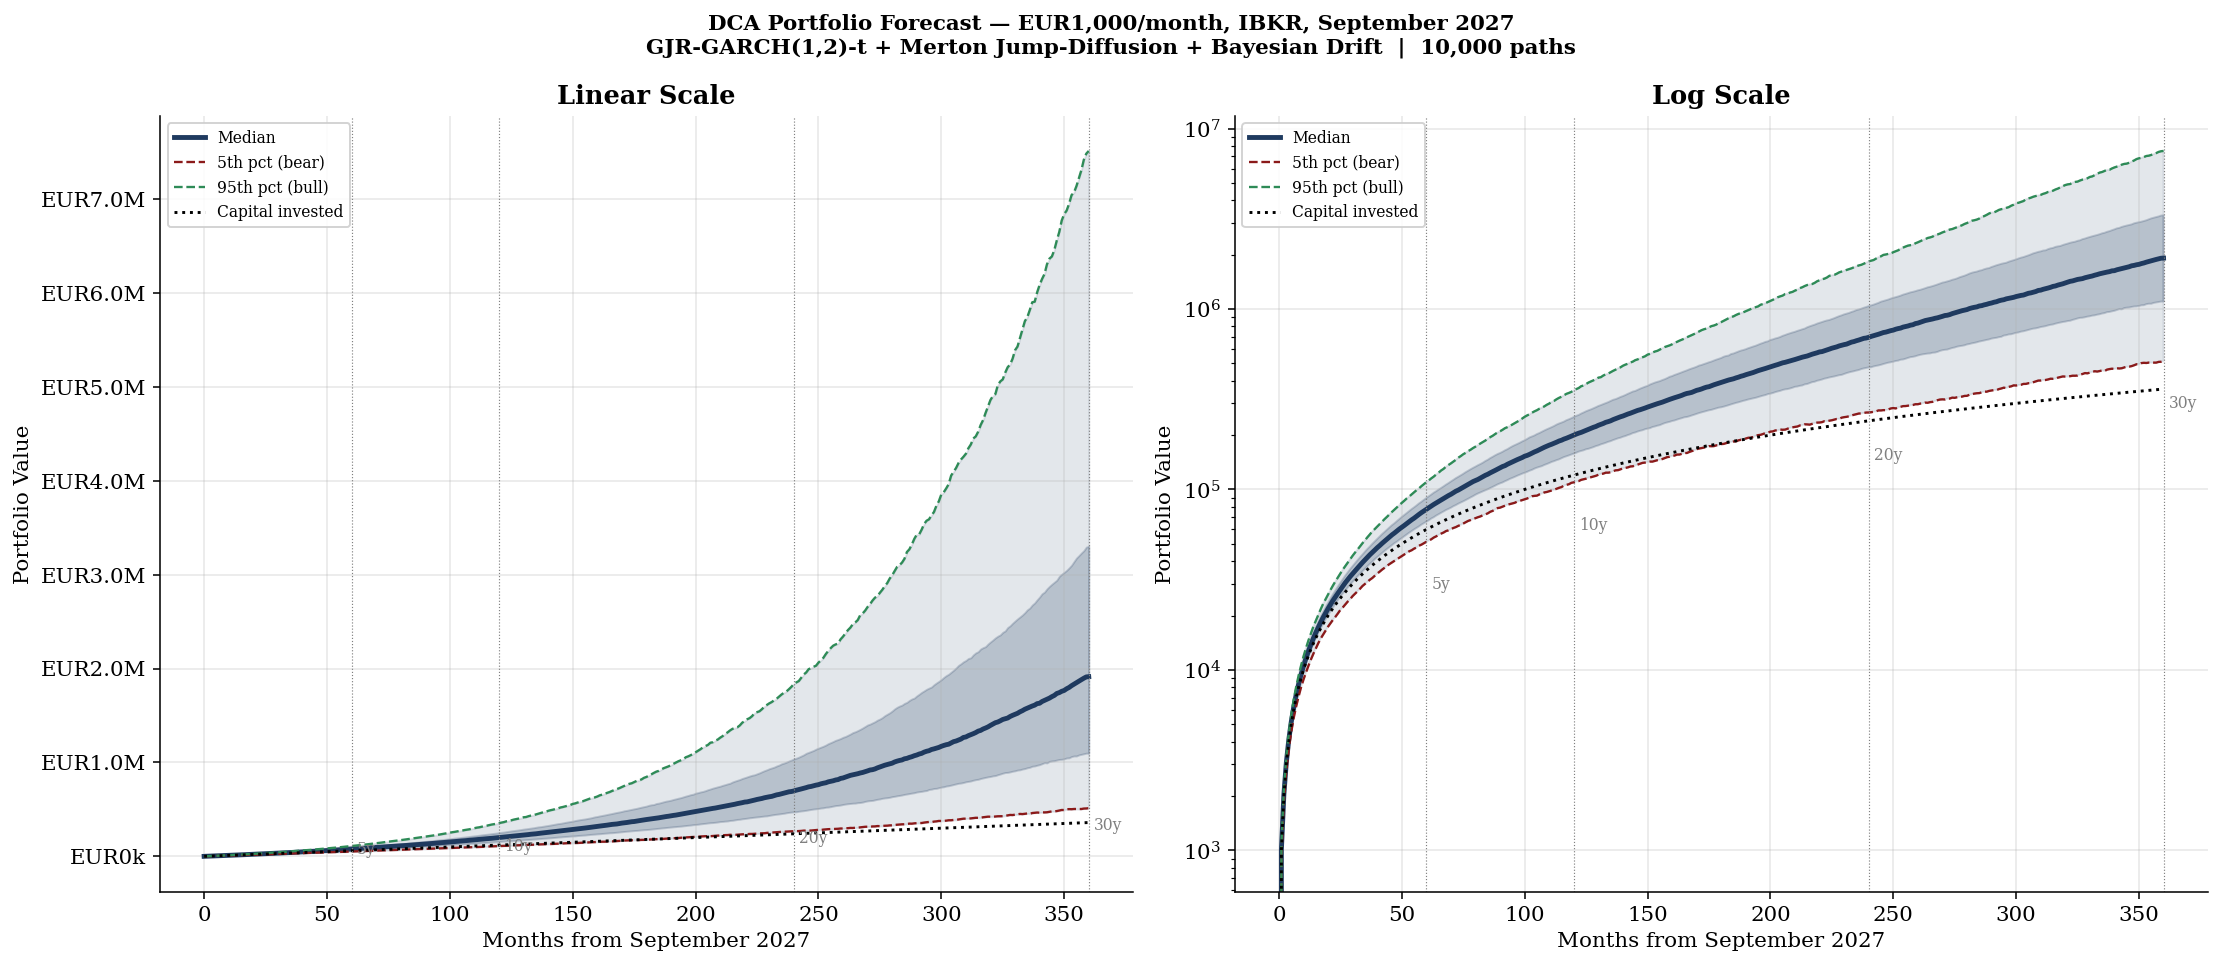

In [20]:
# ── Fan chart (linear + log) ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    f'DCA Portfolio Forecast — EUR1,000/month, IBKR, {START_LABEL}\n'
    'GJR-GARCH(1,2)-t + Merton Jump-Diffusion + Bayesian Drift  |  10,000 paths',
    fontsize=11, fontweight='bold')

for ax, log_scale, title in zip(axes, [False, True], ['Linear Scale', 'Log Scale']):
    ma  = np.arange(portfolio.shape[1])
    inv = MONTHLY_INVEST * ma
    p5  = np.percentile(portfolio,  5, axis=0)
    p25 = np.percentile(portfolio, 25, axis=0)
    p50 = np.percentile(portfolio, 50, axis=0)
    p75 = np.percentile(portfolio, 75, axis=0)
    p95 = np.percentile(portfolio, 95, axis=0)

    ax.fill_between(ma, p5,  p95,  alpha=0.12, color=PALETTE[0])
    ax.fill_between(ma, p25, p75,  alpha=0.22, color=PALETTE[0])
    ax.plot(ma, p50, color=PALETTE[0], lw=2.5, label='Median')
    ax.plot(ma, p5,  color=PALETTE[3], lw=1.2, ls='--', label='5th pct (bear)')
    ax.plot(ma, p95, color=PALETTE[2], lw=1.2, ls='--', label='95th pct (bull)')
    ax.plot(ma, inv, color='black',    lw=1.5, ls=':',  label='Capital invested')

    for yr in [5, 10, 20, 30]:
        m = yr * 12
        if m < len(ma):
            ax.axvline(m, color='grey', lw=0.6, ls=':')
            ax.text(m + 2, p5[m] * 0.55, f'{yr}y', fontsize=8, color='grey')

    ax.set_xlabel(f'Months from {START_LABEL}'); ax.set_ylabel('Portfolio Value')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'EUR{x/1e6:.1f}M' if x >= 1e6 else f'EUR{x/1e3:.0f}k'))
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    if log_scale: ax.set_yscale('log')

plt.tight_layout()
plt.savefig('v3_fig_fan_chart.png', bbox_inches='tight', dpi=140)
plt.show()

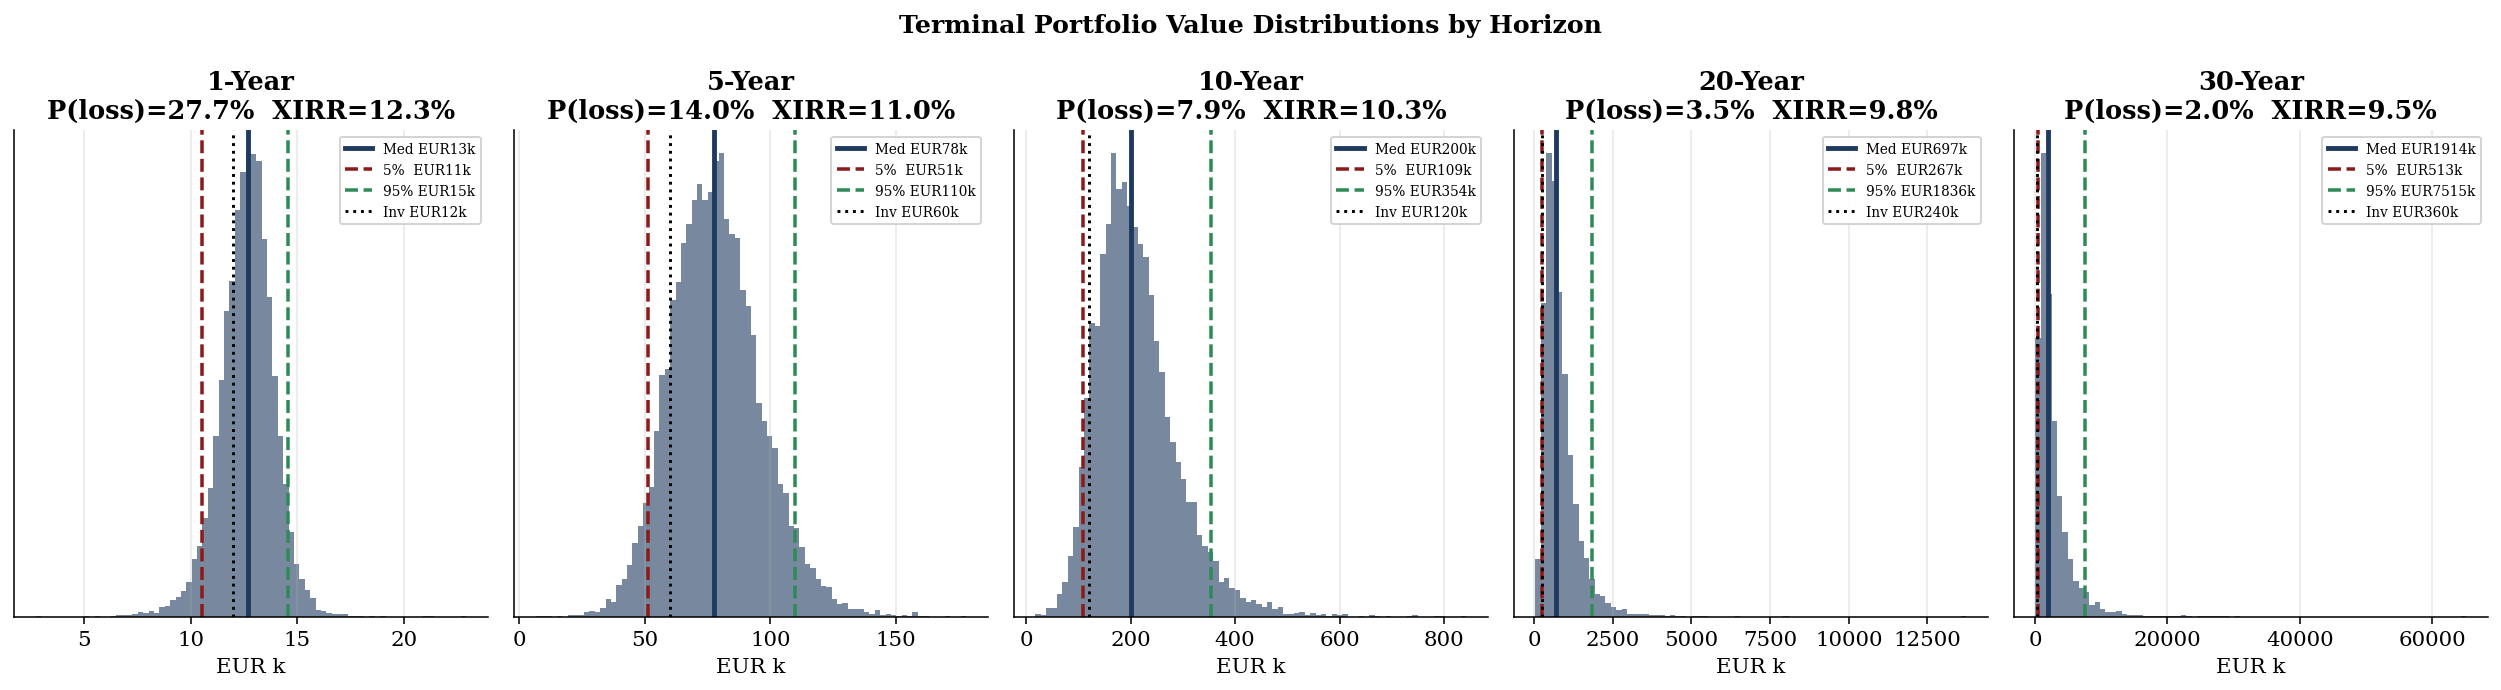

In [21]:
# ── Terminal distributions ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Terminal Portfolio Value Distributions by Horizon', fontsize=13, fontweight='bold')

for ax, yr in zip(axes, [1, 5, 10, 20, 30]):
    n_m = min(int(yr * 12), N_MONTHS)
    pv  = portfolio[:, n_m]
    cap = MONTHLY_INVEST * n_m
    xi  = np.nanmedian(xirr_results[yr])
    p_loss = (pv < cap).mean() * 100

    ax.hist(pv / 1000, bins=80, density=True, color=PALETTE[0], alpha=0.6, edgecolor='none')
    ax.axvline(np.median(pv)          / 1000, color=PALETTE[0], lw=2.5,
               label=f'Med EUR{np.median(pv)/1000:.0f}k')
    ax.axvline(np.percentile(pv,  5)  / 1000, color=PALETTE[3], lw=1.8, ls='--',
               label=f'5%  EUR{np.percentile(pv,5)/1000:.0f}k')
    ax.axvline(np.percentile(pv, 95)  / 1000, color=PALETTE[2], lw=1.8, ls='--',
               label=f'95% EUR{np.percentile(pv,95)/1000:.0f}k')
    ax.axvline(cap / 1000,                    color='black',    lw=1.5, ls=':',
               label=f'Inv EUR{cap/1000:.0f}k')

    ax.set_title(f'{yr}-Year\nP(loss)={p_loss:.1f}%  XIRR={xi*100:.1f}%', fontweight='bold')
    ax.set_xlabel('EUR k'); ax.legend(fontsize=7); ax.yaxis.set_visible(False)

plt.tight_layout()
plt.savefig('v3_fig4_terminal_distributions.png', bbox_inches='tight', dpi=140)
plt.show()

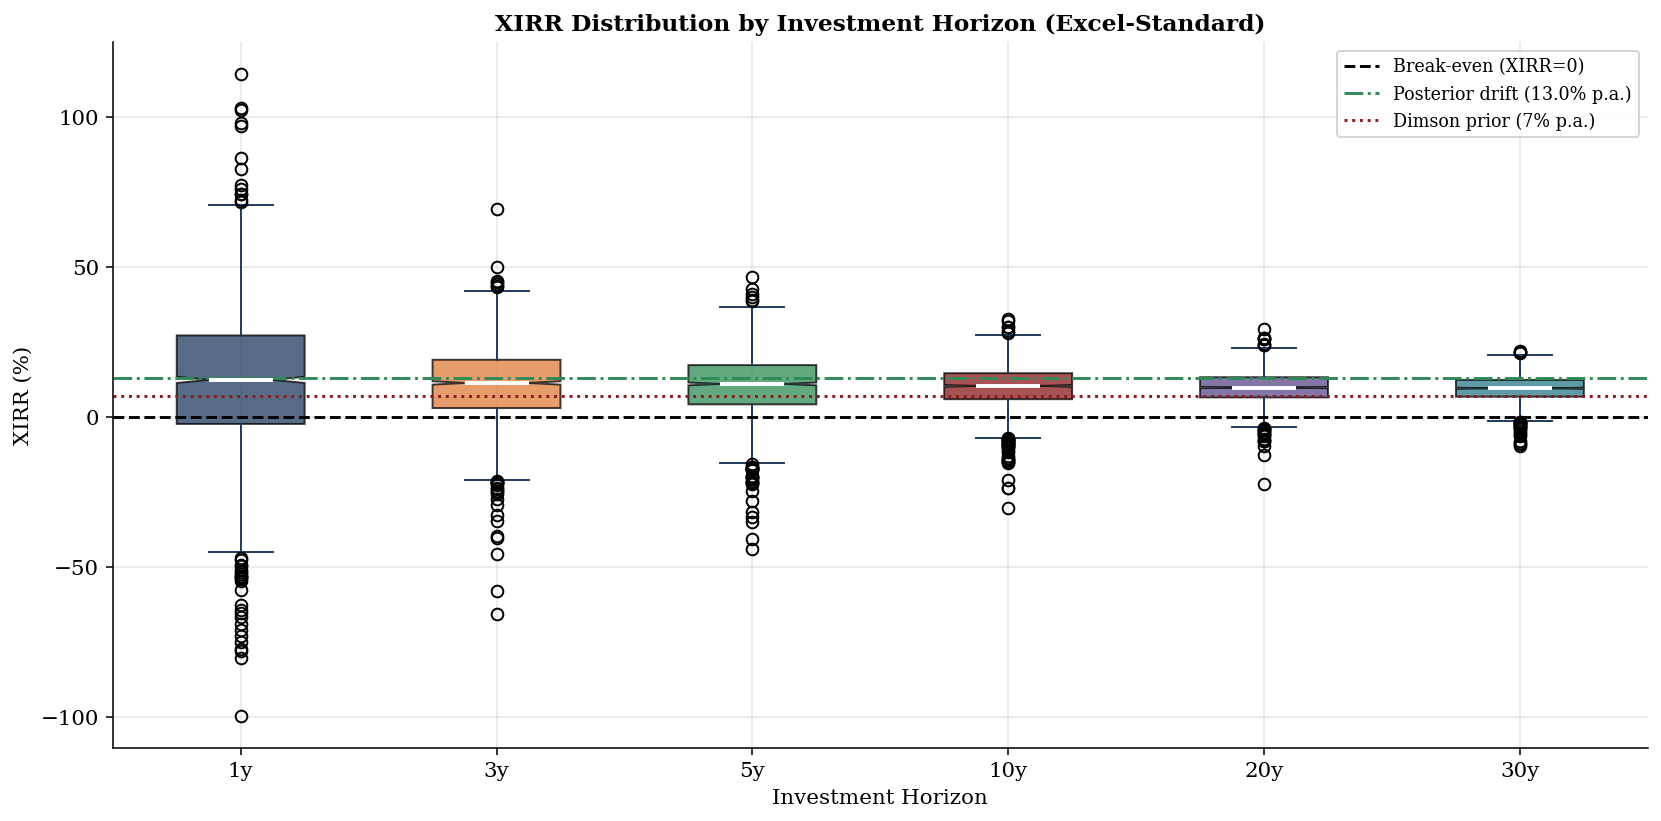

In [22]:
# ── XIRR distribution boxplot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
xd     = [xirr_results[yr][~np.isnan(xirr_results[yr])] * 100 for yr in HORIZONS]
labels = [f'{yr}y' for yr in HORIZONS]

bp = ax.boxplot(xd, labels=labels, patch_artist=True, notch=True,
                medianprops={'color': 'white', 'lw': 2},
                whiskerprops={'color': PALETTE[0]},
                capprops={'color': PALETTE[0]})
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.75)

ax.axhline(0,                        color='black',    lw=1.5, ls='--',
           label='Break-even (XIRR=0)')
ax.axhline(mu_post * TRADING_DAYS,   color=PALETTE[2], lw=1.5, ls='-.',
           label=f'Posterior drift ({mu_post*TRADING_DAYS:.1f}% p.a.)')
ax.axhline(MU_PRIOR_ANN,             color=PALETTE[3], lw=1.5, ls=':',
           label=f'Dimson prior ({MU_PRIOR_ANN:.0f}% p.a.)')
ax.set_title('XIRR Distribution by Investment Horizon (Excel-Standard)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Investment Horizon'); ax.set_ylabel('XIRR (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('v3_fig5_xirr_distribution.png', bbox_inches='tight', dpi=140)
plt.show()

## 12. Summary

In [23]:
print('=' * 74)
print('  VWCE.DE DCA FORECAST — FINAL SUMMARY')
print(f'  Data: {len(ret):,} obs  [{ret.index[0].date()} — {ret.index[-1].date()}]')
print(f'  Model: GJR-GARCH(1,2)-t + Merton jump-diffusion + Bayesian drift')
print('─' * 74)
print(f'  GARCH:  ω={omega:.6f}  α={alpha:.4f}  γ={gamma:.4f}  β1={beta1:.4f}  β2={beta2:.4f}  ν={nu:.2f}')
print(f'          Persistence={persist:.4f}  Uncond.vol={np.sqrt(uncond_var*TRADING_DAYS):.2f}% p.a.')
print(f'  Drift:  MLE={mu_MLE*TRADING_DAYS:.2f}%  Posterior={mu_post*TRADING_DAYS:.2f}%±{se_post*TRADING_DAYS:.2f}%')
print(f'  Jumps:  λ={lambda_d*TRADING_DAYS:.2f}/yr  μ_J={mu_J:.4f}%  σ_J={sig_J:.4f}%')
print(f'  OOS:    MAE={mae:.4f}%/day  MZ β={b_mz[1]:.3f}  R²={r2_mz:.4f}')
print('─' * 74)
print(f'  {"Horizon":>5}  {"Invested":>10}  {"Median":>12}  {"Multiple":>8}  {"XIRR":>8}  {"P(loss)":>8}')
for yr in [1, 5, 10, 20, 30]:
    r = final_results[yr]
    print(f'  {yr:>4}y  EUR{r["cap"]:>9,.0f}  EUR{r["med"]:>11,.0f}  '
          f'{r["med"]/r["cap"]:>7.2f}x  {r["xirr"]*100:>7.2f}%  {r["ploss"]:>7.1f}%')
print('=' * 74)

  VWCE.DE DCA FORECAST — FINAL SUMMARY
  Data: 4,539 obs  [2008-06-27 — 2026-06-18]
  Model: GJR-GARCH(1,2)-t + Merton jump-diffusion + Bayesian drift
──────────────────────────────────────────────────────────────────────────
  GARCH:  ω=0.034412  α=0.0235  γ=0.2142  β1=0.5681  β2=0.2712  ν=6.31
          Persistence=0.9699  Uncond.vol=16.98% p.a.
  Drift:  MLE=19.35%  Posterior=12.97%±2.16%
  Jumps:  λ=1.22/yr  μ_J=-3.2082%  σ_J=1.8269%
  OOS:    MAE=0.6005%/day  MZ β=0.588  R²=0.0693
──────────────────────────────────────────────────────────────────────────
  Horizon    Invested        Median  Multiple      XIRR   P(loss)
     1y  EUR   12,000  EUR     12,699     1.06x    12.32%     27.7%
     5y  EUR   60,000  EUR     77,663     1.29x    10.95%     14.0%
    10y  EUR  120,000  EUR    200,133     1.67x    10.30%      7.9%
    20y  EUR  240,000  EUR    696,587     2.90x     9.76%      3.5%
    30y  EUR  360,000  EUR  1,913,813     5.32x     9.51%      2.0%
